# Scaling Optimal Transport with Hierarchical Refinement
---

**Ce notebook propose un tutorial implémentant la méthode de Hierarchical Refinement en utilsant la library ```OTT-JAX```**

### Rappel du problème :

> Optimal Transport (OT) est super utile en machine learning.

> Mais OT classique (Sinkhorn) explose en mémoire sur de gros jeux de données.

### Solution proposée :

Hierarchical Refinement (HiRef) résout ce problème en utilisant peu de mémoire, tout en fournissant une bijection.

### Plan du notebook :

1. Générer des données

2. Appliquer Low-rank OT

3. Appliquer Hierarchical Refinement

4. Visualiser et comparer

---

Notebook of work for implementing Hierarchical Refinement for OT

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from ott.geometry import pointcloud
from ott.solvers.linear.sinkhorn import Sinkhorn
from ott.solvers.linear.sinkhorn_lr import LRSinkhorn
from ott.tools.k_means import k_means
from ott.problems.linear import linear_problem
from ott.tools import plot


from typing import Tuple
import sys

In [2]:
def partition_points(X: jnp.ndarray, k: int, rng: jax.random.PRNGKey) -> jnp.ndarray:
    """
    Partitionne l'ensemble de points X en k clusters en utilisant K-means.

    Paramètres :
    - X : jnp.ndarray de forme (N, d), ensemble de points à partitionner.
    - k : int, nombre de clusters.
    - rng : jax.random.PRNGKey, clé aléatoire pour l'initialisation.

    Retourne :
    - assignments : jnp.ndarray de forme (N,), indices des clusters pour chaque point.
    """
    geom = pointcloud.PointCloud(X, X)
    result = k_means(geom, k=k, rng=rng)
    return result.assignment


In [ ]:
def hierarchical_refinement(X: jnp.ndarray, Y: jnp.ndarray, rank_schedule: list, rng: jax.random.PRNGKey = jax.random.key(0)) -> jnp.ndarray:
    """
    Applique l'algorithme de Hiérarchical Refinement pour approximer le transport optimal entre X et Y.

    Paramètres :
    - X : jnp.ndarray de forme (N, d), premier ensemble de points.
    - Y : jnp.ndarray de forme (N, d), second ensemble de points.
    - rank_schedule : liste d'entiers, nombre de clusters à chaque niveau de la hiérarchie.
    - rng : jax.random.PRNGKey, clé aléatoire pour l'initialisation.

    Retourne :
    - assignments : jnp.ndarray de forme (N,), indices des correspondances finales entre X et Y.
    """
    N = X.shape[0]
    assignments = jnp.arange(N)
    
    for i, rank in enumerate(rank_schedule):
        rng, rng_X, rng_Y = jax.random.split(rng, 3)
        # Partitionner X et Y en clusters
        assignment_X = partition_points(X, rank, rng_X)
        assignment_Y = partition_points(Y, rank, rng_Y)
        new_assignments = jnp.zeros_like(assignments)
        for cluster_id in range(rank):
            idx_X = jnp.where(assignment_X == cluster_id)[0]
            idx_Y = jnp.where(assignment_Y == cluster_id)[0]
            if idx_X.size == 0 or idx_Y.size == 0:
                continue
            X_sub = X[idx_X]
            Y_sub = Y[idx_Y]
            # On assigne à tous les points le poids
            a = jnp.ones((X_sub.shape[0],)) / X_sub.shape[0]
            b = jnp.ones((Y_sub.shape[0],)) / Y_sub.shape[0]
            geom = pointcloud.PointCloud(X_sub, Y_sub)
            ot_prob = linear_problem.LinearProblem(geom, a, b)
            solver = LRSinkhorn(rank=rank)
            out = solver(ot_prob)
            transport_matrix = out.matrix

            # Trouver les correspondances maximales
            sub_assignments = jnp.argmax(transport_matrix, axis=1)
            # Mettre à jour les correspondances globales
            new_assignments = new_assignments.at[idx_X].set(idx_Y[sub_assignments])

        
        # Mettre à jour X et Y pour le niveau suivant
        X = X[new_assignments]
        Y = Y[new_assignments]
        assignments = new_assignments
    return assignments


## Génération de données

In [4]:
sys.path.insert(0, '../nbk_HiRef/')

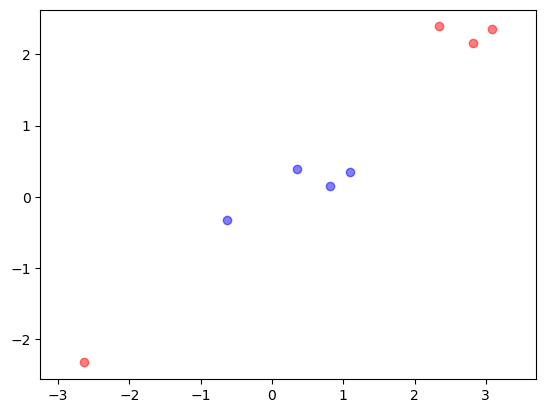

In [5]:
import toy_example

X1, X2 = toy_example.generate_sample_data(N = 4)

# On transforme les vecteurs X1 et X2 au format jnp
X1 = jnp.array(X1)
X2 = jnp.array(X2)

In [6]:
X1.shape

(4, 2)

In [7]:
# plt.scatter(X1[:, 0], X1[:, 1], label="Source", alpha=0.6)
# plt.scatter(X2[:, 0], X2[:, 1], label="Target", alpha=0.6)
# plt.legend()
# plt.title("Source and Target point clouds")
# plt.show()

## Low-Rank OT brut
A partir de ce tuto [OTT-JAX Low-Rank Sinkhorn](https://ott-jax.readthedocs.io/en/stable/tutorials/linear/300_LRSinkhorn.html)

---

Les algorithmes de transport optimal, tels que Sinkhorn ou LRSinkhorn dans la bibliothèque OTT-JAX, 
nécessitent des distributions de probabilité en entrée. 

Cela signifie que les poids a et b doivent être des vecteurs de probabilités, 
c'est-à-dire des vecteurs non négatifs dont la somme est égale à 1.

---


In [8]:
# On transforme les vecteurs numpy X1 et X2 en vecteur JNP
X1 = jnp.array(X1)
X2 = jnp.array(X2)

# On assigne à tous les points le poids
a = jnp.ones((X1.shape[0],)) / X1.shape[0]
b = jnp.ones((X2.shape[0],)) / X2.shape[0]


### Classic Sinkhorn

In [9]:
geom = pointcloud.PointCloud(X1, X2, epsilon=0.1)
ot_prob = linear_problem.LinearProblem(geom, a, b)

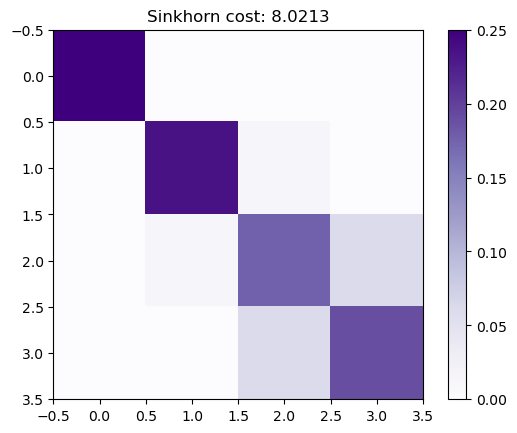

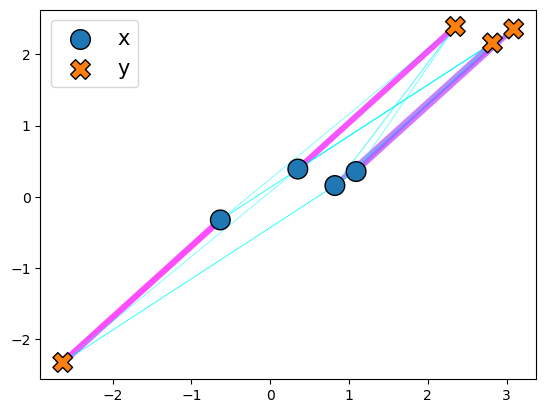

In [10]:
solver = Sinkhorn()
ot_sink = solver(ot_prob)

plt.imshow(ot_sink.matrix, cmap="Purples")
plt.title(f"Sinkhorn cost: {ot_sink.primal_cost:.4f}")
plt.colorbar()
plt.show()
plott = plot.Plot()
_ = plott(ot_sink)

### Low-rank Sinkhorn

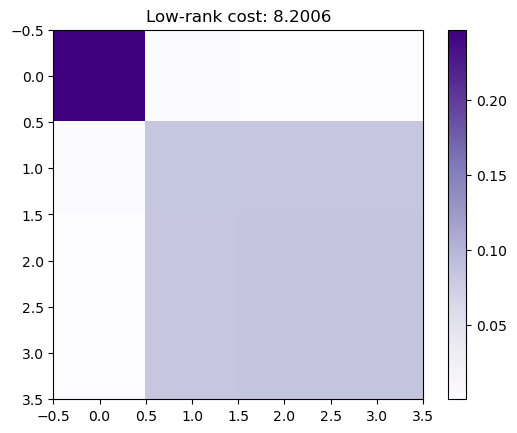

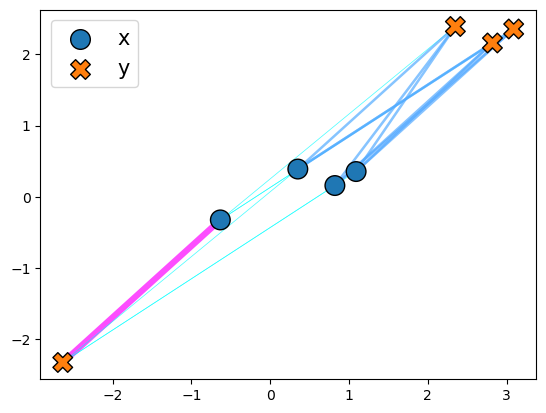

In [11]:
n = X1.shape[0]

solver = LRSinkhorn(rank=int(n / 2)) # Possibility to increase to rank to improve precision and reduce Transport cost
ot_lr = solver(ot_prob)

plt.imshow(ot_lr.matrix, cmap="Purples")
plt.colorbar()
plt.title(f"Low-rank cost: {ot_lr.primal_cost:.4f}")
plt.show()
plott = plot.Plot()
_ = plott(ot_lr)

## Hierarchical Refinement

In [12]:
ot_lr.matrix

Array([[2.4724354e-01, 2.2941539e-03, 2.1233065e-05, 1.9444844e-04],
       [2.8665825e-03, 8.1934221e-02, 8.2667902e-02, 8.2612000e-02],
       [1.3843027e-04, 8.2823284e-02, 8.3590537e-02, 8.3532073e-02],
       [3.1018058e-07, 8.2868308e-02, 8.3637260e-02, 8.3578661e-02]],      dtype=float32)

In [13]:
mapping = hierarchical_refinement(
    X1, X2,
    rank_schedule=[2, 2, 4],  # Exemple de découpe hiérarchique
)

In [14]:
mapping

Array([0, 1, 2, 3], dtype=int32)

TypeError: Invalid shape (4,) for image data

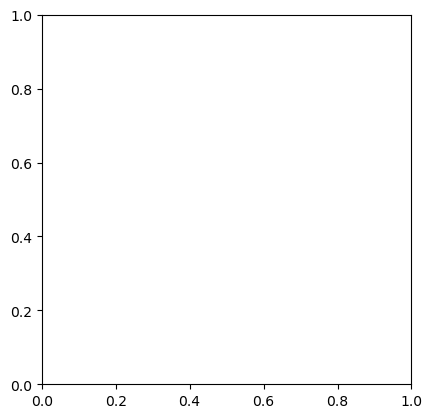

In [15]:
plt.imshow(mapping, cmap="Purples")
#plt.title(f"Sinkhorn cost: {ot_sink.primal_cost:.4f}")
plt.colorbar()
plt.show()
plott = plot.Plot()
_ = plott(ot_sink)

In [ ]:
import jax
import jax.numpy as jnp
from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn
from ott.solvers.linear.sinkhorn import SinkhornOutput

class HierarchicalRefinement(sinkhorn.Sinkhorn):
    def __init__(self, assignments, **kwargs):
        super().__init__(**kwargs)
        self.assignments = jnp.array(assignments)

    def __call__(self, ot_prob: linear_problem.LinearProblem) -> SinkhornOutput:
        # Appliquer le raffinement hiérarchique basé sur self.assignments
        # Par exemple, réordonner les points sources et cibles selon les clusters
        # puis appliquer l'algorithme de Sinkhorn sur les sous-problèmes

        # Pour simplifier, nous utilisons directement la méthode __call__ de la classe parente
        return super().__call__(ot_prob)

In [ ]:
# Exemple d'utilisation
assignments = [0, 2, 1, 9, 7, 1, 6, 12, 1, 3, 3, 4, 3, 3, 14, 7]
jnp_assignments = jnp.array(assignments)
solver = HierarchicalRefinement(assignments=jnp_assignments)
ot_sol = solver(ot_prob)
print(f"Coût du transport : {ot_sol.primal_cost}")

TypeError: Argument '<__main__.HierarchicalRefinement object at 0x7fea5c374170>' of type '<class '__main__.HierarchicalRefinement'>' is not a valid JAX type

## Visualisation des correspondances

## Comparaison des Coûts

# Conclusion

Résumé :

- HiRef permet d’obtenir un transport optimal bijectif.
- Il économise beaucoup de mémoire. (stockage linéaire VS n^2)
- Il est compétitif en coût avec Sinkhorn mais scalable à des millions de points.

Liens :
- Lien vers le papier original 📄.
- Lien vers le code HiRef sur GitHub 🔗.